### 1) Required installs

In [2]:
!pip -q install transformers datasets evaluate accelerate scikit-learn matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00


### 2) Imports

In [1]:
import os
import json
import time
import random
import hashlib
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed,
)

PROJECT_DIR = Path("/content/maintainers-copilot")
SPLITS_DIR = PROJECT_DIR / "data" / "splits"
MODELS_DIR = PROJECT_DIR / "models" / "classifier"
MANIFESTS_DIR = PROJECT_DIR / "models" / "manifests"
REPORTS_DIR = PROJECT_DIR / "data" / "reports"

for p in [SPLITS_DIR, MODELS_DIR, MANIFESTS_DIR, REPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Using device:", "cuda" if torch.cuda.is_available() else "cpu")

Using device: cuda


### 3) Loading the json files

In [3]:
def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

train_df = load_jsonl(SPLITS_DIR / "train.jsonl")
val_df = load_jsonl(SPLITS_DIR / "val.jsonl")
test_df = load_jsonl(SPLITS_DIR / "test.jsonl")

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

print("\nTrain label distribution:")
print(train_df["mapped_label"].value_counts())

print("\nVal label distribution:")
print(val_df["mapped_label"].value_counts())

print("\nTest label distribution:")
print(test_df["mapped_label"].value_counts())

Train: (318, 11)
Val: (80, 11)
Test: (100, 11)

Columns:
['external_id', 'repo', 'number', 'title', 'body', 'state', 'labels', 'mapped_label', 'created_at', 'closed_at', 'url']

Train label distribution:
mapped_label
bug         162
docs         91
question     48
feature      17
Name: count, dtype: int64

Val label distribution:
mapped_label
bug         41
docs        23
question    12
feature      4
Name: count, dtype: int64

Test label distribution:
mapped_label
bug         55
question    25
docs        15
feature      5
Name: count, dtype: int64


### 4) Build input text

Combines issue title and body into one text field for the transformer.

In [4]:
def clean_text(value):
    if value is None:
        return ""
    if isinstance(value, float) and pd.isna(value):
        return ""
    return str(value)

def build_text(row):
    title = clean_text(row.get("title", ""))
    body = clean_text(row.get("body", ""))
    return f"Title: {title}\n\nBody: {body}"

for df in [train_df, val_df, test_df]:
    df["text"] = df.apply(build_text, axis=1)

print(train_df[["text", "mapped_label"]].head(2).to_string())

                                                                                                                                                                                                                                                                                                                                                                                                                           text mapped_label
0                                                                                                                                                                                                          Title: e2e-test.sh should wait for container start\n\nBody: Right now the test will assume that when cloudcfg.sh returns the container is up and running. We need to wait until the container is actually running.\n          bug
1  Title: Port forwarding should be through iptables\n\nBody: As we've disabled docker managing IP tables we no longer get it setting up expli

### 5) Label mapping

In [5]:
LABELS = ["bug", "docs", "feature", "question"]

label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = sorted(set(df["mapped_label"]) - set(LABELS))
    if missing:
        raise ValueError(f"{name} contains unknown labels: {missing}")

    absent = sorted(set(LABELS) - set(df["mapped_label"]))
    if absent:
        raise ValueError(f"{name} is missing labels: {absent}")

for df in [train_df, val_df, test_df]:
    df["label"] = df["mapped_label"].map(label2id)

print("label2id:", label2id)
print("id2label:", id2label)

label2id: {'bug': 0, 'docs': 1, 'feature': 2, 'question': 3}
id2label: {0: 'bug', 1: 'docs', 2: 'feature', 3: 'question'}


### 6) Convert pandas dataframes to Hugging Face datasets

Prepares the train/validation/test data for transformer training.

In [6]:
keep_cols = ["text", "label", "mapped_label"]

train_ds = Dataset.from_pandas(train_df[keep_cols], preserve_index=False)
val_ds = Dataset.from_pandas(val_df[keep_cols], preserve_index=False)
test_ds = Dataset.from_pandas(test_df[keep_cols], preserve_index=False)

dataset = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'mapped_label'],
        num_rows: 318
    })
    validation: Dataset({
        features: ['text', 'label', 'mapped_label'],
        num_rows: 80
    })
    test: Dataset({
        features: ['text', 'label', 'mapped_label'],
        num_rows: 100
    })
})

### 7) Loading tokenizer and tokenizing text

In [7]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 384

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_dataset = dataset.map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(tokenized_dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/318 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'mapped_label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 318
    })
    validation: Dataset({
        features: ['text', 'label', 'mapped_label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 80
    })
    test: Dataset({
        features: ['text', 'label', 'mapped_label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 100
    })
})


### 8) Compute class weights

Gives more weight to minority classes, especially feature.

In [8]:
train_labels = train_df["label"].to_numpy()

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(list(range(len(LABELS)))),
    y=train_labels,
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Class weights:")
for label, weight in zip(LABELS, class_weights.tolist()):
    print(f"{label}: {weight:.4f}")

Class weights:
bug: 0.4907
docs: 0.8736
feature: 4.6765
question: 1.6562


### 9) Define weighted Trainer

Customizes the loss function so the model does not ignore minority classes.

In [9]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        weights = self.class_weights.to(logits.device)
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

### 10) Metrics

In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "weighted_f1": f1_score(labels, preds, average="weighted", zero_division=0),
    }

### 11) Load model

Explanation: creates a DistilBERT classifier with 4 output labels.

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
)

print(model.config)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_dim": 3072,
  "id2label": {
    "0": "bug",
    "1": "docs",
    "2": "feature",
    "3": "question"
  },
  "initializer_range": 0.02,
  "label2id": {
    "bug": 0,
    "docs": 1,
    "feature": 2,
    "question": 3
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "vocab_size": 30522
}



### 12) Training configurations

In [13]:
OUTPUT_DIR = "/content/day2_distilbert_issue_classifier"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    seed=SEED,

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,

    # replaces deprecated warmup_ratio
    warmup_steps=20,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
)

print("Trainer ready.")

Trainer ready.


### 13) Starting fine tuning

In [14]:
start_time = time.time()

train_result = trainer.train()

training_seconds = round(time.time() - start_time, 2)

print("Training finished.")
print("Training seconds:", training_seconds)
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.302416,1.291485,0.650000,0.393228,0.595176
2,1.090534,1.117876,0.687500,0.508929,0.675446
3,0.840871,1.029610,0.700000,0.618481,0.707007
4,0.743301,0.991094,0.687500,0.595437,0.696339
5,0.699546,0.934026,0.712500,0.609328,0.715722


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training finished.
Training seconds: 67.89
TrainOutput(global_step=200, training_loss=0.9812729978561401, metrics={'train_runtime': 67.4153, 'train_samples_per_second': 23.585, 'train_steps_per_second': 2.967, 'total_flos': 155125891430496.0, 'train_loss': 0.9812729978561401, 'epoch': 5.0})


### 14) Evaluation on validation and test

In [15]:
val_metrics = trainer.evaluate(tokenized_dataset["validation"])
test_metrics = trainer.evaluate(tokenized_dataset["test"])

print("Validation metrics:")
print(json.dumps(val_metrics, indent=2))

print("\nTest metrics:")
print(json.dumps(test_metrics, indent=2))

Validation metrics:
{
  "eval_loss": 1.0294973850250244,
  "eval_accuracy": 0.7,
  "eval_macro_f1": 0.6184807256235827,
  "eval_weighted_f1": 0.7070068027210884,
  "eval_runtime": 0.3342,
  "eval_samples_per_second": 239.408,
  "eval_steps_per_second": 14.963,
  "epoch": 5.0
}

Test metrics:
{
  "eval_loss": 1.152835488319397,
  "eval_accuracy": 0.5,
  "eval_macro_f1": 0.381971631971632,
  "eval_weighted_f1": 0.5059395559395559,
  "eval_runtime": 0.3883,
  "eval_samples_per_second": 257.539,
  "eval_steps_per_second": 18.028,
  "epoch": 5.0
}


### 15) Generate predictions and classification report

Gives per-class F1 scores, which is needed for DECISIONS.md and MODEL_CARD.md.

In [16]:
test_pred_output = trainer.predict(tokenized_dataset["test"])
test_logits = test_pred_output.predictions
test_true = test_pred_output.label_ids
test_pred = np.argmax(test_logits, axis=-1)

report_dict = classification_report(
    test_true,
    test_pred,
    target_names=LABELS,
    zero_division=0,
    output_dict=True,
)

report_text = classification_report(
    test_true,
    test_pred,
    target_names=LABELS,
    zero_division=0,
)

print(report_text)

with open(REPORTS_DIR / "transformer_classification_report.json", "w", encoding="utf-8") as f:
    json.dump(report_dict, f, indent=2)

with open(REPORTS_DIR / "transformer_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

              precision    recall  f1-score   support

         bug       0.75      0.49      0.59        55
        docs       0.45      0.67      0.54        15
     feature       0.00      0.00      0.00         5
    question       0.32      0.52      0.39        25

    accuracy                           0.50       100
   macro avg       0.38      0.42      0.38       100
weighted avg       0.56      0.50      0.51       100



### 16) Confusion matrix

,pred_bug,pred_docs,pred_feature,pred_question
true_bug,27,2,0,26
true_docs,4,10,0,1
true_feature,0,4,0,1
true_question,5,6,1,13


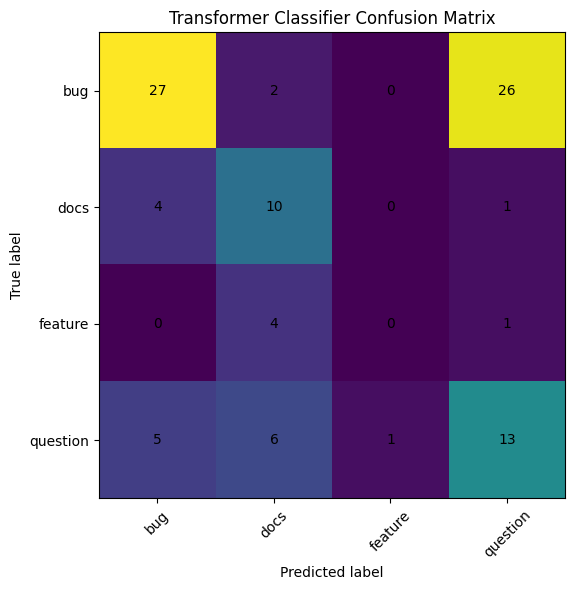

In [17]:
cm = confusion_matrix(test_true, test_pred, labels=list(range(len(LABELS))))

cm_df = pd.DataFrame(cm, index=[f"true_{x}" for x in LABELS], columns=[f"pred_{x}" for x in LABELS])
display(cm_df)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Transformer Classifier Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(range(len(LABELS)), LABELS, rotation=45)
plt.yticks(range(len(LABELS)), LABELS)

for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "transformer_confusion_matrix.png", dpi=160)
plt.show()

### 17) Save predictions

Saves test predictions for later evaluation and comparison with the LLM baseline.

In [18]:
probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()

pred_rows = []
for i, row in test_df.reset_index(drop=True).iterrows():
    pred_id = int(test_pred[i])
    true_id = int(test_true[i])

    pred_rows.append({
        "id": row.get("id"),
        "url": row.get("url"),
        "title": row.get("title"),
        "true_label": id2label[true_id],
        "pred_label": id2label[pred_id],
        "confidence": float(probs[i][pred_id]),
        "probabilities": {
            id2label[j]: float(probs[i][j])
            for j in range(len(LABELS))
        },
    })

pred_path = REPORTS_DIR / "transformer_test_predictions.jsonl"

with pred_path.open("w", encoding="utf-8") as f:
    for row in pred_rows:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print("Saved:", pred_path)

Saved: /content/maintainers-copilot/data/reports/transformer_test_predictions.jsonl


### 18) Save the trained model

In [19]:
FINAL_MODEL_DIR = MODELS_DIR / "distilbert_issue_classifier"

if FINAL_MODEL_DIR.exists():
    shutil.rmtree(FINAL_MODEL_DIR)

trainer.save_model(str(FINAL_MODEL_DIR))
tokenizer.save_pretrained(str(FINAL_MODEL_DIR))

print("Saved model to:", FINAL_MODEL_DIR)
print("Files:")
for path in FINAL_MODEL_DIR.iterdir():
    print(" -", path.name)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: /content/maintainers-copilot/models/classifier/distilbert_issue_classifier
Files:
 - model.safetensors
 - tokenizer_config.json
 - config.json
 - tokenizer.json
 - training_args.bin


### 19) Compute SHA-256 hashes

Creates hashes for model files. This is needed for boot checks and MODEL_CARD.md.

In [20]:
def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

model_hashes = {}

for path in FINAL_MODEL_DIR.rglob("*"):
    if path.is_file():
        rel = str(path.relative_to(FINAL_MODEL_DIR))
        model_hashes[rel] = sha256_file(path)

print(json.dumps(model_hashes, indent=2)[:3000])

{
  "model.safetensors": "1272346e8a012d34965338160d0fc20d81638369405cacaf75c87de47e746a7e",
  "tokenizer_config.json": "797ed9ba72b500001971b827b0040b8743def8ec38f9cd4cda4c4945734d3596",
  "config.json": "f53e956cef60fefd7a65b94cd3859c0120ecac89185f63e34029a5244d0fb71e",
  "tokenizer.json": "c571f1b1973291370192db62060efdfb564c9a11865c568693ac7420e857cf55",
  "training_args.bin": "a40762957cc1c5cb00dab457c8d0eea9b9cafbb23f6fb3383c366aee4fc968b2"
}


### 20) Save manifest

Stores the model metadata, label mapping, metrics, training setup, and hashes.

In [21]:
manifest = {
    "model_name": "distilbert_issue_classifier",
    "base_model": MODEL_NAME,
    "task": "issue_classification",
    "labels": LABELS,
    "label2id": label2id,
    "id2label": {str(k): v for k, v in id2label.items()},
    "max_length": MAX_LENGTH,
    "seed": SEED,
    "training": {
        "epochs": training_args.num_train_epochs,
        "learning_rate": training_args.learning_rate,
        "train_batch_size": training_args.per_device_train_batch_size,
        "eval_batch_size": training_args.per_device_eval_batch_size,
        "weight_decay": training_args.weight_decay,
        "warmup_ratio": training_args.warmup_ratio,
        "class_weights": {
            label: float(weight)
            for label, weight in zip(LABELS, class_weights.tolist())
        },
        "training_seconds": training_seconds,
    },
    "data": {
        "repo": "kubernetes/kubernetes",
        "train_size": len(train_df),
        "val_size": len(val_df),
        "test_size": len(test_df),
        "train_distribution": train_df["mapped_label"].value_counts().to_dict(),
        "val_distribution": val_df["mapped_label"].value_counts().to_dict(),
        "test_distribution": test_df["mapped_label"].value_counts().to_dict(),
    },
    "metrics": {
        "validation": val_metrics,
        "test": test_metrics,
        "test_classification_report": report_dict,
    },
    "hashes": model_hashes,
}

manifest_path = MANIFESTS_DIR / "classifier_manifest.json"

with manifest_path.open("w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:", manifest_path)

Saved manifest: /content/maintainers-copilot/models/manifests/classifier_manifest.json


### 21) Creates model card

In [25]:
macro_f1 = report_dict["macro avg"]["f1-score"]
accuracy = report_dict["accuracy"]

model_card = f"""
# Model Card — Issue Classifier

## Model

Fine-tuned DistilBERT classifier.

Base model:
{MODEL_NAME}

---

## Task

Classify GitHub issues into four maintainer triage labels:

- bug
- docs
- feature
- question

---

## Dataset

Source repository:
kubernetes/kubernetes

Label mapping:

- kind/bug → bug
- kind/documentation → docs
- kind/feature → feature
- kind/support → question

---

## Split sizes

Train: {len(train_df)}

Validation: {len(val_df)}

Test: {len(test_df)}

---

## Label distribution

### Train

{train_df["mapped_label"].value_counts().to_string()}

### Validation

{val_df["mapped_label"].value_counts().to_string()}

### Test

{test_df["mapped_label"].value_counts().to_string()}

---

## Imbalance handling

Class-weighted cross entropy was used.

Class weights:

{json.dumps(manifest["training"]["class_weights"], indent=2)}

---

## Hyperparameters

epochs = {training_args.num_train_epochs}

learning_rate = {training_args.learning_rate}

train_batch_size = {training_args.per_device_train_batch_size}

eval_batch_size = {training_args.per_device_eval_batch_size}

max_length = {MAX_LENGTH}

weight_decay = {training_args.weight_decay}

warmup_steps = {training_args.warmup_steps}

seed = {SEED}

---

## Test metrics

accuracy = {accuracy:.4f}

macro_f1 = {macro_f1:.4f}

weighted_f1 = {test_metrics.get("test_weighted_f1", test_metrics.get("eval_weighted_f1", 0.0)):.4f}

---

## Per-class report

{report_text}

---

## Deployment note

This model is selected because inference cost is lower than using an LLM for every request.

---

## Limitations

- Small filtered dataset
- Feature class remains underrepresented
- Label noise may exist
- Macro-F1 matters more than accuracy

---

## Artifact hashes

{json.dumps(model_hashes, indent=2)}
"""

model_card_path = PROJECT_DIR / "MODEL_CARD.md"

with open(model_card_path, "w", encoding="utf-8") as f:
    f.write(model_card)

print("Saved:", model_card_path)

print("\nPreview:\n")
print(model_card[:2500])

Saved: /content/maintainers-copilot/MODEL_CARD.md

Preview:


# Model Card — Issue Classifier

## Model

Fine-tuned DistilBERT classifier.

Base model:
distilbert-base-uncased

---

## Task

Classify GitHub issues into four maintainer triage labels:

- bug
- docs
- feature
- question

---

## Dataset

Source repository:
kubernetes/kubernetes

Label mapping:

- kind/bug → bug
- kind/documentation → docs
- kind/feature → feature
- kind/support → question

---

## Split sizes

Train: 318

Validation: 80

Test: 100

---

## Label distribution

### Train

mapped_label
bug         162
docs         91
question     48
feature      17

### Validation

mapped_label
bug         41
docs        23
question    12
feature      4

### Test

mapped_label
bug         55
question    25
docs        15
feature      5

---

## Imbalance handling

Class-weighted cross entropy was used.

Class weights:

{
  "bug": 0.49074074625968933,
  "docs": 0.8736263513565063,
  "feature": 4.676470756530762,
  "question":

### 22) Zip artifcats

In [26]:
ARTIFACT_ZIP = "/content/day2_transformer_classifier_artifacts.zip"

if os.path.exists(ARTIFACT_ZIP):
    os.remove(ARTIFACT_ZIP)

shutil.make_archive(
    base_name=ARTIFACT_ZIP.replace(".zip", ""),
    format="zip",
    root_dir=PROJECT_DIR,
    base_dir="."
)

print("Created:", ARTIFACT_ZIP)

Created: /content/day2_transformer_classifier_artifacts.zip


In [27]:
from google.colab import files

files.download(ARTIFACT_ZIP)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>